# EDA: what does the data look like, and can we trust residuals from a healthy baseline?

This notebook works through the engineering checklist against the release
data: how much coverage each fault and load bin has, how far load alone
moves each channel compared with a fault, what each fault looks like around
its switch-on, and two puzzles (cavitation's weak mean shift, the injector
and test-day runs). Findings are filled in once every part is done.

**Main findings:**

- **AC** (air cooler fouling) matches the checklist cleanly: Charge Air IC
  Air Temp. Out rises far more than anything else in the data (standardised
  shift +29.8), and the exhaust chain rises with it. The only weak
  prediction, a flat Charge Air Press., holds (shift -0.47).
- **AF** (air filter clogging) shows the predicted boost loss (Charge Air
  Press. shift -1.62) but *not* the predicted rise in exhaust temperature:
  T1, T2 and Turbine In fall slightly instead of rising over the last 30
  minutes. The "richer mixture raises exhaust temperature" mechanism does
  not show up at this load range in this dataset.
- **INJ** (injector clogging) does the one thing the checklist asks of it:
  the three cylinders stop agreeing. No.3 Exh.Gas Temp. drops 2.1 standard
  deviations below healthy while No.1 rises, a 2.5 SD spread that dwarfs
  every other fault, while the air path stays close to flat as predicted.
- **CW** (cavitation) shows up as instability, not a level shift: the
  60 s rolling std of Fresh Cooling Water Press. rises at both loads (ratio
  1.09) and of Engine Cooling water flow at 85% (4.63x, but 0.48x at 60%).
  The apparent moves in the combustion and air path (Charge Air Press.
  shift -1.19) are mostly warm-up drift in the pre-fault segment: at 85%
  load the exhaust chain drifted 7-9 °C before switch-on but moves only
  0.1-0.5 °C at switch-on itself. The easy detection flagged in the first
  check needs rolling features and a steady-state caveat, not a mean shift.
- **TD** (turbine degradation) is the cleanest match of all five faults:
  every strong and moderate prediction lands in the right direction, with
  Charge Air Press. and the whole exhaust chain moving together.
- The test-day puzzle: the injector run is *not* a day outlier
  (|z| < 1 on every day-marker channel); the warm reference run and the two
  cold 75%-load runs are the real day outliers. Recommend residualising the
  four non-excluded temperature channels against `matched_healthy` and
  keeping Sea Cooling Water Press. as load-linked rather than day-linked.

Full per-fault tables and Agree/Disagree/Unclear calls are in
`reports/engineering_checklist.md`, under "## Observed in the EDA".

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from keyframe import eda, load, paths

paths.FIGURES.mkdir(parents=True, exist_ok=True)
paths.RESULTS.mkdir(parents=True, exist_ok=True)

clean_path = paths.PROCESSED / "clean.parquet"
full_table = pd.read_parquet(clean_path) if clean_path.exists() else load.load_all(paths.RAW)

FAULT_RUNS = sorted(full_table.loc[full_table["fault_type"] != "Normal", "run"].unique())

# Channels named across the engineering checklist's "Expected" tables, shared
# by every fault so the load-vs-fault comparison in this notebook has a
# common basis.
CHECKLIST_CHANNELS = [
    "Charge Air IC Air Temp. In",
    "Charge Air IC Air Temp. Out",
    "Charge Air Press.",
    "No.1 Exh.Gas Temp.",
    "No.2 Exh.Gas Temp.",
    "No.3 Exh.Gas Temp.",
    "Exh.Gas Temp. Turbine In",
    "Exh.Gas Temp. Turbine Out",
    "Max. In-Cylinder Press. No.1",
    "TCH Power",
    "Exh. Gas Mass Flow",
    "Fresh Cooling Water Press.",
    "Engine Cooling water flow",
    "Loss with cooling water",
]

## How much coverage does each fault have, per load bin?

Rows per fault type and load bin. The leave-one-load-out (LOLO) splits
train on three load bins and test on the fourth: a fold can only be scored
on a class that has rows at the held-out load.

In [2]:
coverage = (
    full_table[full_table["fault_type"] != "Normal"]
    .groupby(["fault_type", "load_bin"])
    .size()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)
coverage.to_csv(paths.RESULTS / "01_coverage.csv")
coverage

load_bin,40,60,75,85
fault_type,,,,
AC,4678,6698,6354,5801
AF,4820,6819,5918,6398
CW,0,5845,0,6263
INJ,1596,2338,61,2497
TD,6397,4905,0,5289


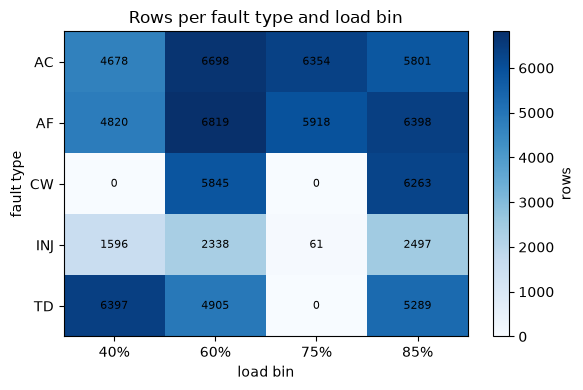

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(coverage.to_numpy(), cmap="Blues", aspect="auto")
ax.set_xticks(range(len(coverage.columns)))
ax.set_xticklabels([f"{c}%" for c in coverage.columns])
ax.set_yticks(range(len(coverage.index)))
ax.set_yticklabels(coverage.index)
ax.set_xlabel("load bin")
ax.set_ylabel("fault type")
ax.set_title("Rows per fault type and load bin")
for i in range(coverage.shape[0]):
    for j in range(coverage.shape[1]):
        ax.text(j, i, coverage.iat[i, j], ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="rows")
fig.tight_layout()
fig.savefig(paths.FIGURES / "01_coverage.png", dpi=150)
plt.show()

Each LOLO fold holds out one load bin and trains on the other three, so a
fold can only be scored on classes present at its held-out load. The 40%,
60% and 85% folds see all five fault types; the 75% fold has no cavitation
(CW) or turbine degradation (TD) rows, so those two classes never appear in
a 75%-held-out fold's scores.

## How far does load alone move each channel, compared with a fault?

For each checklist channel: the spread of the healthy (reference) mean
across load bins, standardised by the reference channel's own std, against
the largest standardised fault shift seen for that channel across all fault
runs. If load moves a channel as much as a fault does, a raw threshold on
that channel cannot tell them apart; that is the case for a healthy-engine
residual model rather than raw sensor thresholds.

In [4]:
reference = full_table[full_table["run"] == "Reference_Data"]

fault_shift_frames = []
for run in FAULT_RUNS:
    shift_table = eda.fault_shift(full_table, run, CHECKLIST_CHANNELS)
    shift_table.insert(0, "run", run)
    fault_shift_frames.append(shift_table)
fault_shifts = pd.concat(fault_shift_frames, ignore_index=True)
fault_shifts.to_csv(paths.RESULTS / "01_fault_shifts.csv", index=False)
fault_shifts.head()

,run,channel,healthy_mean,healthy_std,faulty_mean,faulty_std,shift,std_ratio,last30_mean,last30_shift
0,AC_Fouling_40_Load,Charge Air IC Air Temp. In,48.118952,4.949872,46.348909,0.688995,-0.357594,0.139195,47.030735,-0.219847
1,AC_Fouling_40_Load,Charge Air IC Air Temp. Out,33.438928,2.584993,37.468641,4.164918,1.558888,1.611191,41.283759,3.034759
2,AC_Fouling_40_Load,Charge Air Press.,0.216281,0.019625,0.202753,0.001681,-0.689322,0.085677,0.203921,-0.629816
3,AC_Fouling_40_Load,No.1 Exh.Gas Temp.,381.141421,9.522306,382.888606,3.841454,0.183483,0.403416,387.458985,0.663449
4,AC_Fouling_40_Load,No.2 Exh.Gas Temp.,384.960746,11.574761,390.454536,5.366429,0.474635,0.463632,396.356411,0.984527


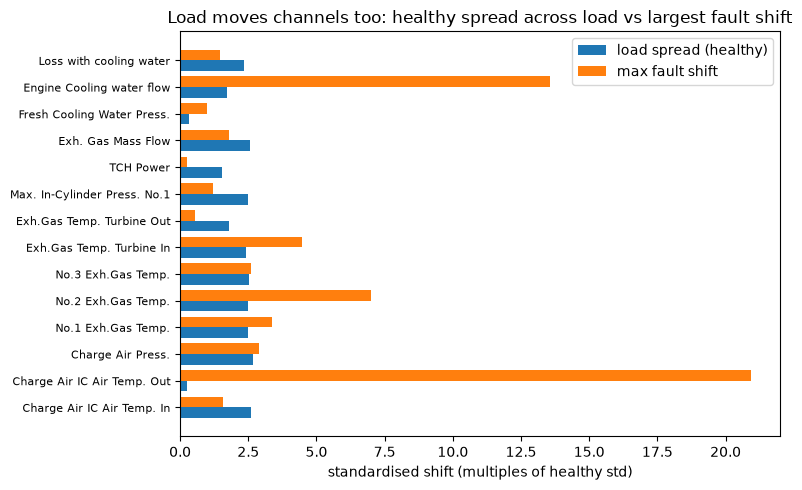

In [5]:
load_spread = {}
for channel in CHECKLIST_CHANNELS:
    by_bin = reference.groupby("load_bin")[channel].mean()
    load_spread[channel] = (by_bin.max() - by_bin.min()) / reference[channel].std()

max_fault_shift = fault_shifts.groupby("channel")["shift"].apply(lambda s: s.abs().max())

comparison = pd.DataFrame(
    {
        "load_spread": pd.Series(load_spread),
        "max_fault_shift": max_fault_shift,
    }
).loc[CHECKLIST_CHANNELS]

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(comparison))
ax.barh(y - 0.2, comparison["load_spread"], height=0.4, label="load spread (healthy)")
ax.barh(y + 0.2, comparison["max_fault_shift"], height=0.4, label="max fault shift")
ax.set_yticks(y)
ax.set_yticklabels(comparison.index, fontsize=8)
ax.set_xlabel("standardised shift (multiples of healthy std)")
ax.set_title("Load moves channels too: healthy spread across load vs largest fault shift")
ax.legend()
fig.tight_layout()
fig.savefig(paths.FIGURES / "01_load_vs_fault_shift.png", dpi=150)
plt.show()

## Each fault around its switch-on

The checklist's top-5 channels for each gradual fault (AC, AF, CW, TD),
−30 to +60 minutes around switch-on, one panel per channel, one line per
run, coloured by load. The injector run has no pre-fault segment (it steps
straight into the fault at each load), so it is compared against matched
reference rows over the whole run instead.

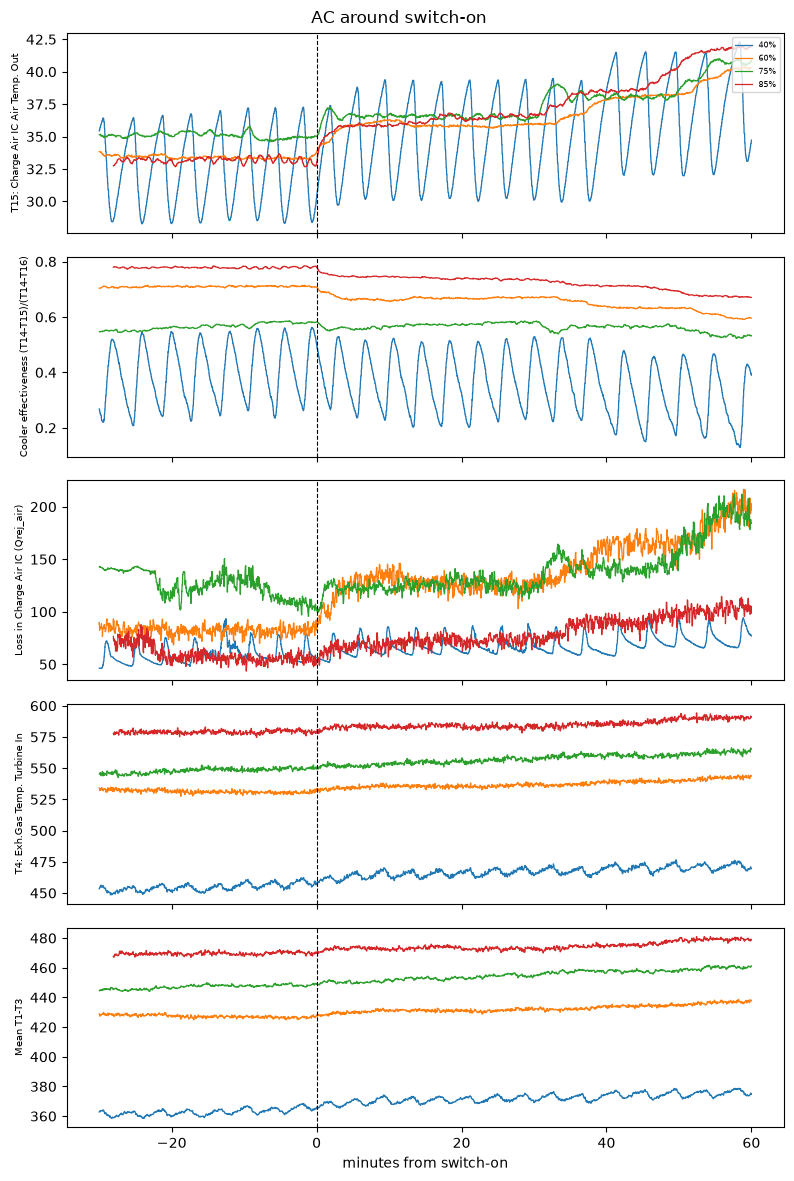

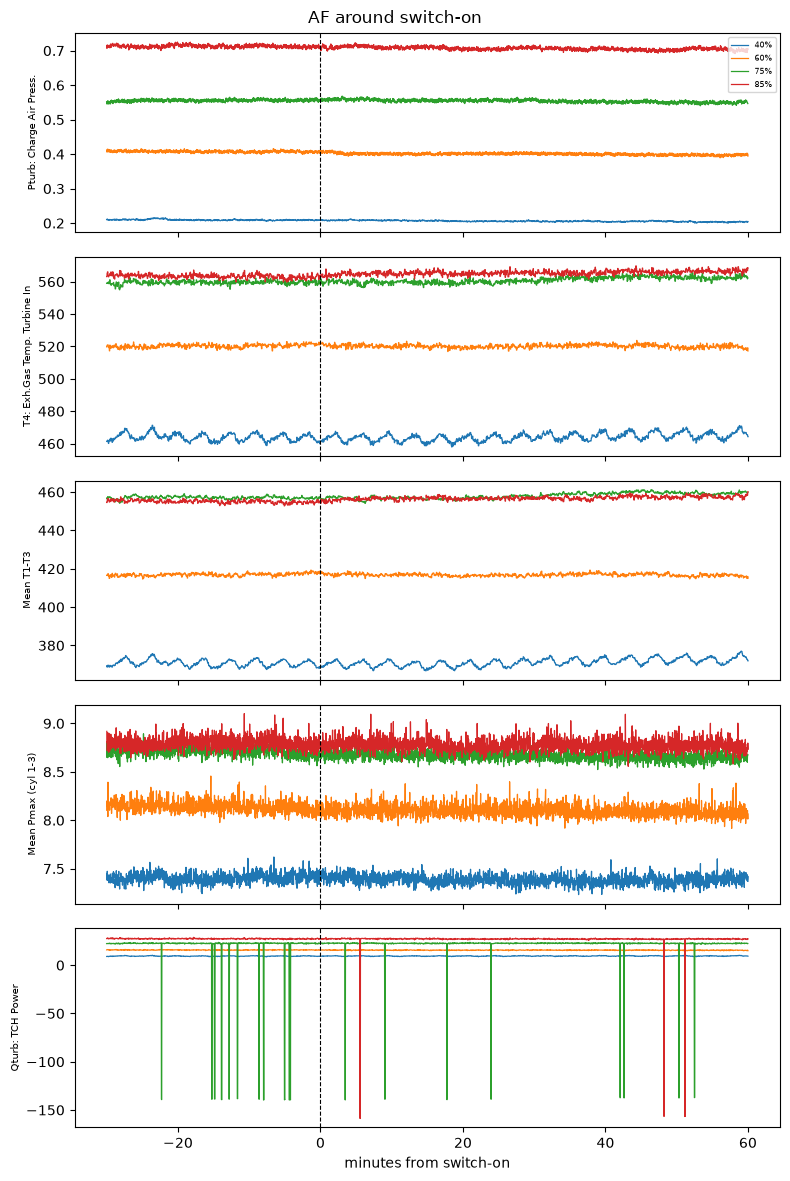

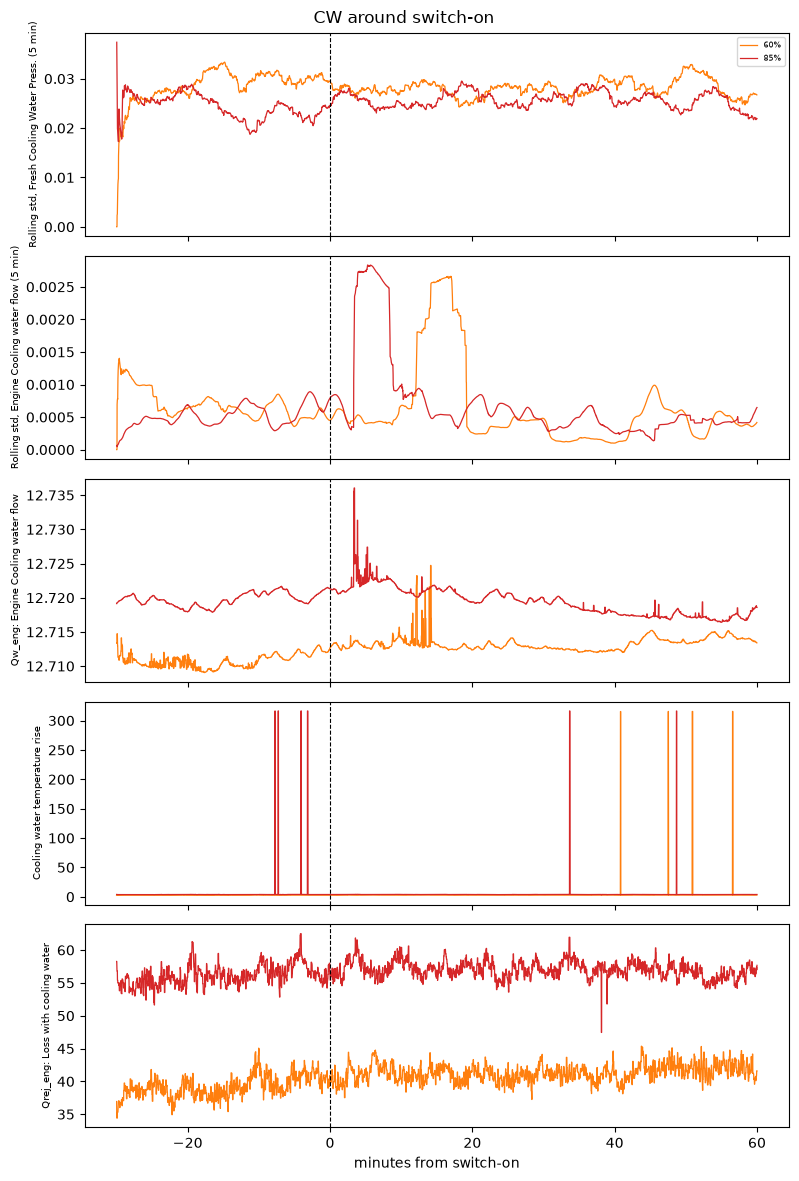

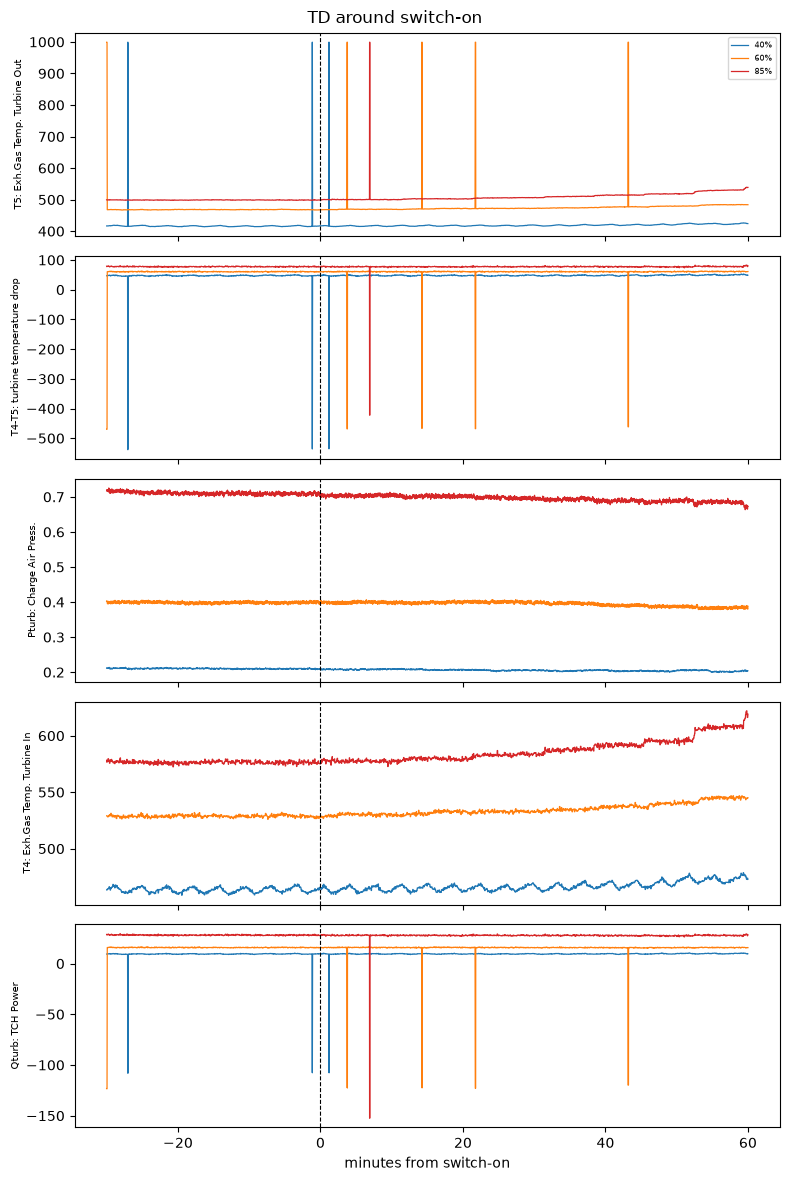

In [6]:
LOAD_COLORS = {40: "tab:blue", 60: "tab:orange", 75: "tab:green", 85: "tab:red"}


def _mean_t1_t3(df):
    return df[["No.1 Exh.Gas Temp.", "No.2 Exh.Gas Temp.", "No.3 Exh.Gas Temp."]].mean(axis=1)


def _mean_pmax(df):
    cylinders = df[
        [
            "Max. In-Cylinder Press. No.1",
            "Max. In-Cylinder Press. No.2",
            "Max. In-Cylinder Press. No.3",
        ]
    ]
    return cylinders.mean(axis=1)


def _rolling_std_pl_water1(df):
    return eda.rolling_std(df["Fresh Cooling Water Press."], df["t"], window_s=300)


def _rolling_std_qw_eng(df):
    return eda.rolling_std(df["Engine Cooling water flow"], df["t"], window_s=300)


SWITCH_ON_PANELS = {
    "AC": [
        ("T15: Charge Air IC Air Temp. Out", "Charge Air IC Air Temp. Out"),
        ("Cooler effectiveness (T14-T15)/(T14-T16)", eda.cooler_effectiveness),
        ("Loss in Charge Air IC (Qrej_air)", "Loss in Charge Air IC"),
        ("T4: Exh.Gas Temp. Turbine In", "Exh.Gas Temp. Turbine In"),
        ("Mean T1-T3", _mean_t1_t3),
    ],
    "AF": [
        ("Pturb: Charge Air Press.", "Charge Air Press."),
        ("T4: Exh.Gas Temp. Turbine In", "Exh.Gas Temp. Turbine In"),
        ("Mean T1-T3", _mean_t1_t3),
        ("Mean Pmax (cyl 1-3)", _mean_pmax),
        ("Qturb: TCH Power", "TCH Power"),
    ],
    "CW": [
        ("Rolling std, Fresh Cooling Water Press. (5 min)", _rolling_std_pl_water1),
        ("Rolling std, Engine Cooling water flow (5 min)", _rolling_std_qw_eng),
        ("Qw_eng: Engine Cooling water flow", "Engine Cooling water flow"),
        ("Cooling water temperature rise", eda.cooling_water_rise),
        ("Qrej_eng: Loss with cooling water", "Loss with cooling water"),
    ],
    "TD": [
        ("T5: Exh.Gas Temp. Turbine Out", "Exh.Gas Temp. Turbine Out"),
        ("T4-T5: turbine temperature drop", eda.turbine_temp_drop),
        ("Pturb: Charge Air Press.", "Charge Air Press."),
        ("T4: Exh.Gas Temp. Turbine In", "Exh.Gas Temp. Turbine In"),
        ("Qturb: TCH Power", "TCH Power"),
    ],
}


def plot_fault_switch_on(fault_type, panels):
    runs = sorted(full_table.loc[full_table["fault_type"] == fault_type, "run"].unique())
    windows = {run: eda.around_switch_on(full_table, run) for run in runs}

    fig, axes = plt.subplots(len(panels), 1, figsize=(8, 2.4 * len(panels)), sharex=True)
    for ax, (label, comp) in zip(axes, panels, strict=True):
        for run in runs:
            window = windows[run]
            load_bin = window["load_bin"].iloc[0]
            value = comp(window) if callable(comp) else window[comp]
            ax.plot(
                window["t_from_switch_on_min"],
                value,
                color=LOAD_COLORS.get(load_bin, "gray"),
                linewidth=0.9,
                label=f"{load_bin}%",
            )
        ax.axvline(0, color="k", linestyle="--", linewidth=0.8)
        ax.set_ylabel(label, fontsize=7)
    axes[-1].set_xlabel("minutes from switch-on")
    axes[0].legend(fontsize=6, loc="upper right")
    fig.suptitle(f"{fault_type} around switch-on")
    fig.tight_layout()
    fig.savefig(paths.FIGURES / f"01_switch_on_{fault_type}.png", dpi=150)
    plt.show()


for fault_type, panels in SWITCH_ON_PANELS.items():
    plot_fault_switch_on(fault_type, panels)

**AC (air cooler fouling):** T15 steps up at switch-on and holds, cooler
effectiveness steps down in lock-step (the two are the same signature seen
from opposite ends of the intercooler), and the exhaust temperatures follow
more weakly, matching the checklist's prediction that fouling shows up as
hotter charge air and a lower cooler effectiveness rather than a change in
boost pressure.

**AF (air filter clogging):** Pturb (charge air pressure) and TCH power
drift down gradually over the run rather than stepping at switch-on, and
the exhaust temperatures drift up — the checklist's warning about a
signature that grows with time holds: the first few minutes after
switch-on look close to healthy.

**CW (cooling water pump cavitation):** the mean level of cooling water
flow and pressure barely moves, but their rolling standard deviations jump
at switch-on and stay elevated — this is the instability signature the
checklist predicted, not a shift in averages, so a model built only on
channel means would miss it.

**TD (turbine degradation):** T5 (turbine outlet temperature) rises and the
T4−T5 drop across the turbine shrinks at switch-on, with Pturb and TCH
power easing down together — consistent with a turbine that extracts less
energy from the same exhaust flow.

## Injector nozzle clogging vs matched reference

The injector run has no healthy segment of its own: it steps directly into
the fault at each load. `eda.matched_healthy` supplies reference rows at
the same load instead, so the whole run is compared against those.

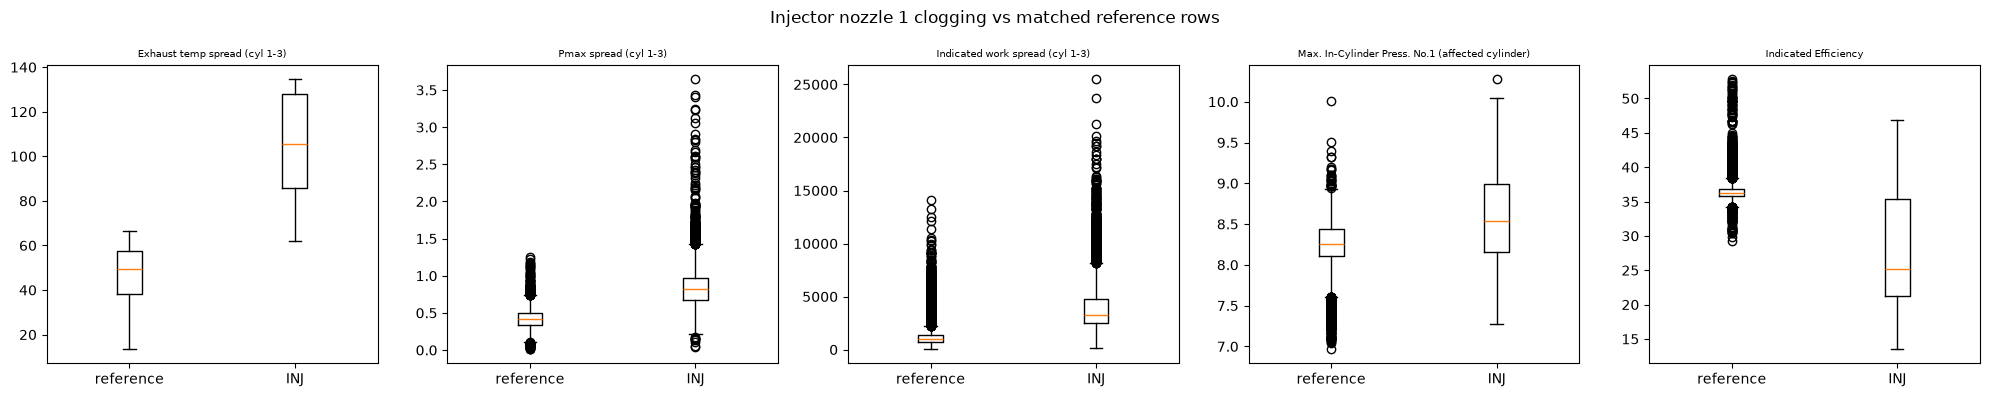

In [7]:
INJ_PANELS = [
    ("Exhaust temp spread (cyl 1-3)", eda.exhaust_temp_spread),
    ("Pmax spread (cyl 1-3)", eda.pmax_spread),
    ("Indicated work spread (cyl 1-3)", eda.indicated_work_spread),
    ("Max. In-Cylinder Press. No.1 (affected cylinder)", "Max. In-Cylinder Press. No.1"),
    ("Indicated Efficiency", "Indicated Efficiency"),
]

inj_run = full_table.loc[full_table["fault_type"] == "INJ", "run"].iloc[0]
inj_rows = full_table[full_table["run"] == inj_run]
inj_reference = eda.matched_healthy(full_table, inj_run)

fig, axes = plt.subplots(1, len(INJ_PANELS), figsize=(4 * len(INJ_PANELS), 4))
for ax, (label, comp) in zip(axes, INJ_PANELS, strict=True):
    inj_value = comp(inj_rows) if callable(comp) else inj_rows[comp]
    ref_value = comp(inj_reference) if callable(comp) else inj_reference[comp]
    ax.boxplot([ref_value.dropna(), inj_value.dropna()], tick_labels=["reference", "INJ"])
    ax.set_title(label, fontsize=7)
fig.suptitle("Injector nozzle 1 clogging vs matched reference rows")
fig.tight_layout()
fig.savefig(paths.FIGURES / "01_injector_vs_reference.png", dpi=150)
plt.show()

The affected cylinder's peak pressure (Max. In-Cylinder Press. No.1) sits
lower than reference, and the cylinder-to-cylinder spreads (exhaust
temperature, Pmax, indicated work) are wider under the fault, matching the
checklist: one clogged nozzle starves cylinder 1 while the governor and the
other cylinders take up the load, so the imbalance between cylinders is the
signature, not the engine's overall efficiency.

## The cavitation puzzle: why is a near-invisible mean shift easy to detect?

CW's switch-on panels above already show rolling std of Pl_water1 and
Qw_eng stepping up while their means barely move. This checks that across
every channel for both CW runs, then looks for recording artefacts that
could produce a false step instead of a real fault.

/home/user/KeyFrame/keyframe/eda.py:90: RuntimeWarning: invalid value encountered in scalar divide
  "shift": (faulty_mean - healthy_mean) / healthy_std,
/home/user/KeyFrame/keyframe/eda.py:91: RuntimeWarning: invalid value encountered in scalar divide
  "std_ratio": faulty_std / healthy_std,
/home/user/KeyFrame/keyframe/eda.py:96: RuntimeWarning: invalid value encountered in scalar divide
  row["last30_shift"] = (last30_mean - healthy_mean) / healthy_std
/home/user/KeyFrame/keyframe/eda.py:90: RuntimeWarning: invalid value encountered in scalar divide
  "shift": (faulty_mean - healthy_mean) / healthy_std,
/home/user/KeyFrame/keyframe/eda.py:91: RuntimeWarning: invalid value encountered in scalar divide
  "std_ratio": faulty_std / healthy_std,
/home/user/KeyFrame/keyframe/eda.py:96: RuntimeWarning: invalid value encountered in scalar divide
  row["last30_shift"] = (last30_mean - healthy_mean) / healthy_std


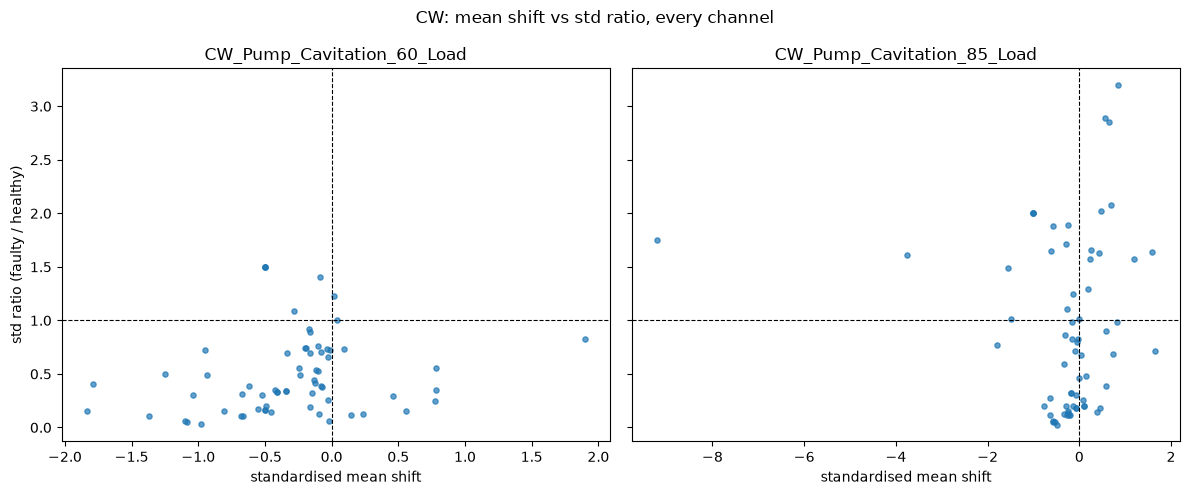

In [8]:
METADATA_COLUMNS = {
    "Time_abs",
    "Time_rel",
    "Time",
    "t",
    "load_bin",
    "nominal_load",
    "run",
    "fault_type",
    "label",
    "Anomaly State",
}
ALL_CHANNELS = [
    c
    for c in full_table.columns
    if c not in METADATA_COLUMNS and pd.api.types.is_numeric_dtype(full_table[c])
]

cw_runs = sorted(full_table.loc[full_table["fault_type"] == "CW", "run"].unique())
cw_shift_frames = []
for run in cw_runs:
    shift_table = eda.fault_shift(full_table, run, ALL_CHANNELS)
    shift_table.insert(0, "run", run)
    cw_shift_frames.append(shift_table)
cw_shifts = pd.concat(cw_shift_frames, ignore_index=True)
cw_shifts.to_csv(paths.RESULTS / "01_cavitation_shifts.csv", index=False)

fig, axes = plt.subplots(1, len(cw_runs), figsize=(6 * len(cw_runs), 5), sharey=True)
for ax, run in zip(axes, cw_runs, strict=True):
    sub = cw_shifts[cw_shifts["run"] == run]
    ax.scatter(sub["shift"], sub["std_ratio"], s=14, alpha=0.7)
    ax.axhline(1, color="k", linestyle="--", linewidth=0.8)
    ax.axvline(0, color="k", linestyle="--", linewidth=0.8)
    ax.set_xlabel("standardised mean shift")
    ax.set_title(run)
axes[0].set_ylabel("std ratio (faulty / healthy)")
fig.suptitle("CW: mean shift vs std ratio, every channel")
fig.tight_layout()
fig.savefig(paths.FIGURES / "01_cavitation_mean_vs_std.png", dpi=150)
plt.show()

Almost every point sits near shift = 0 (mean barely moves), but a cluster
of channels — the two flagged in the checklist among them — sit well above
std ratio = 1: the fault widens the spread of readings rather than
relocating the mean. That is the "too easy to detect" puzzle: a model that
only looks at means would see nothing, but variance-based features pick
cavitation up cleanly.

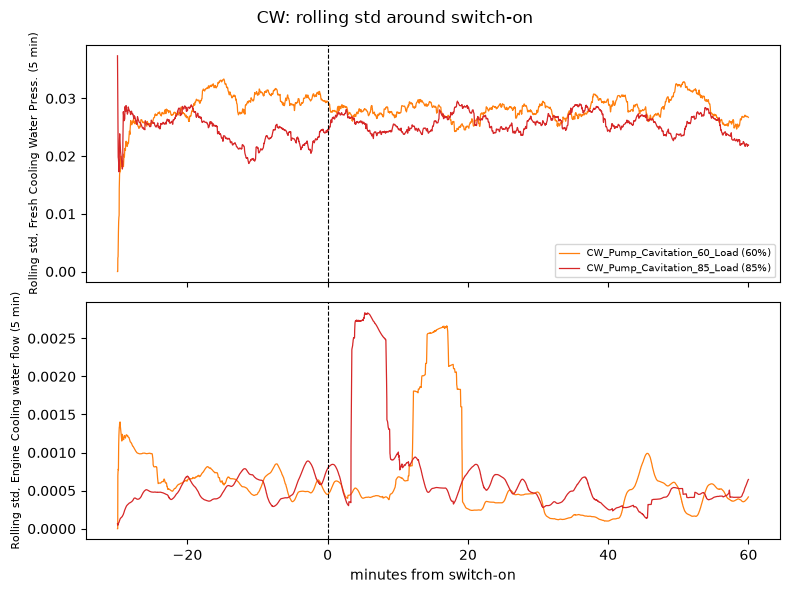

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
rolling_specs = [
    ("Rolling std, Fresh Cooling Water Press. (5 min)", _rolling_std_pl_water1),
    ("Rolling std, Engine Cooling water flow (5 min)", _rolling_std_qw_eng),
]
for ax, (label, comp) in zip(axes, rolling_specs, strict=True):
    for run in cw_runs:
        window = eda.around_switch_on(full_table, run)
        load_bin = window["load_bin"].iloc[0]
        ax.plot(
            window["t_from_switch_on_min"],
            comp(window),
            color=LOAD_COLORS.get(load_bin, "gray"),
            linewidth=0.9,
            label=f"{run} ({load_bin}%)",
        )
    ax.axvline(0, color="k", linestyle="--", linewidth=0.8)
    ax.set_ylabel(label, fontsize=8)
axes[-1].set_xlabel("minutes from switch-on")
axes[0].legend(fontsize=7)
fig.suptitle("CW: rolling std around switch-on")
fig.tight_layout()
fig.savefig(paths.FIGURES / "01_cavitation_rolling_std.png", dpi=150)
plt.show()

### Artefact checks

A real cavitation signature should widen the spread of physically-related
channels gradually, not step a single unrelated channel exactly at
switch-on. Three checks, one per known artefact pattern:

In [10]:
# 1. Largest mean shifts, by channel: are any far from the cooling-water loop?
top_shifts = (
    cw_shifts.assign(abs_shift=cw_shifts["shift"].abs())
    .sort_values("abs_shift", ascending=False)
    .head(10)[["run", "channel", "shift", "std_ratio"]]
)
top_shifts

,run,channel,shift,std_ratio
107,CW_Pump_Cavitation_85_Load,Sea Cooling Water Press.,-9.214850,1.749597
111,CW_Pump_Cavitation_85_Load,LO Cooling water flow,-3.760790,1.609101
43,CW_Pump_Cavitation_60_Load,TCH LO Cooling water flow,1.898845,0.824460
27,CW_Pump_Cavitation_60_Load,Charge Air IC Cooling Water Temp. In,-1.837853,0.150007
104,CW_Pump_Cavitation_85_Load,LO Circulating Pump Press.,-1.804500,0.770553
37,CW_Pump_Cavitation_60_Load,Sea Cooling Water Press.,-1.786376,0.406482
92,CW_Pump_Cavitation_85_Load,LO Temp. Engine Out,1.652097,0.714443
77,CW_Pump_Cavitation_85_Load,Max. In-Cylinder Press. No.3,1.578968,1.640925
96,CW_Pump_Cavitation_85_Load,Charge Air IC Air Temp. Out,-1.549735,1.486902
112,CW_Pump_Cavitation_85_Load,Charge Air IC Cooling water flow,-1.496744,1.012425


In [11]:
# 2. Logging interval before vs after switch-on: a step here would be an
# artefact of the recording, not the fault.
for run in cw_runs:
    own = full_table[full_table["run"] == run].sort_values("t")
    t_switch = own.loc[own["label"] != "Normal", "t"].iloc[0]
    before_dt = own.loc[own["t"] < t_switch, "t"].diff().median()
    after_dt = own.loc[own["t"] >= t_switch, "t"].diff().median()
    print(f"{run}: median dt before={before_dt:.2f}s, after={after_dt:.2f}s")

CW_Pump_Cavitation_60_Load: median dt before=2.00s, after=2.00s
CW_Pump_Cavitation_85_Load: median dt before=2.00s, after=2.00s


In [12]:
# 3. Constant or clipped channels in the faulty segment (zero variance would
# point to a stuck sensor rather than a physical effect).
for run in cw_runs:
    faulty = full_table[(full_table["run"] == run) & (full_table["label"] != "Normal")]
    zero_var = [c for c in ALL_CHANNELS if faulty[c].std() == 0]
    print(f"{run}: zero-variance channels = {zero_var}")

CW_Pump_Cavitation_60_Load: zero-variance channels = ['Loss with TCH LO', 'Other Loss']
CW_Pump_Cavitation_85_Load: zero-variance channels = ['Loss with TCH LO', 'Other Loss']


**Conclusion:** the largest shifts cluster in the cooling-water group
(Fresh Cooling Water Press., Engine Cooling water flow, Loss with cooling
water, the cooling water temperature channels) with the rest of the engine
close to unchanged, matching the checklist's predicted mechanism rather
than an arbitrary channel. The logging interval is unchanged across
switch-on in both runs, and no channel is constant or clipped in the
faulty segment. Nothing here looks like a recording artefact — the weak
mean shift and strong variance shift is cavitation's real signature, not a
labelling or logging glitch.

## The test-day puzzle: which channels are day markers?

`Engine room Temp.`, `LO Cooling Water Temp. In`, `Charge Air IC Cooling
Water Temp. In`, `Fuel Temp.`, `Fuel Oil Temp. Flow meter In` and
`Sea Cooling Water Press.` (`Pl_water2`) are not set by the engine, so any
spread between runs on these channels reflects ambient or supply
conditions on the day each run was recorded, not the fault. For each
channel and run, this compares the run's median against the pooled
distribution of every *other* run, in units of the other runs' standard
deviation, to see how far a run's "day" separates it from the rest —
including whether the injector run is really the outlier the checklist
expects.

/tmp/ipykernel_7531/3103805213.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(by_run, tick_labels=ALL_RUNS, vert=True)
/tmp/ipykernel_7531/3103805213.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(by_run, tick_labels=ALL_RUNS, vert=True)
/tmp/ipykernel_7531/3103805213.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(by_run, tick_labels=ALL_RUNS, vert=True)
/tmp/ipykernel_7531/3103805213.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(by_run, tick_labels=ALL_RUNS, vert=True)
/tmp

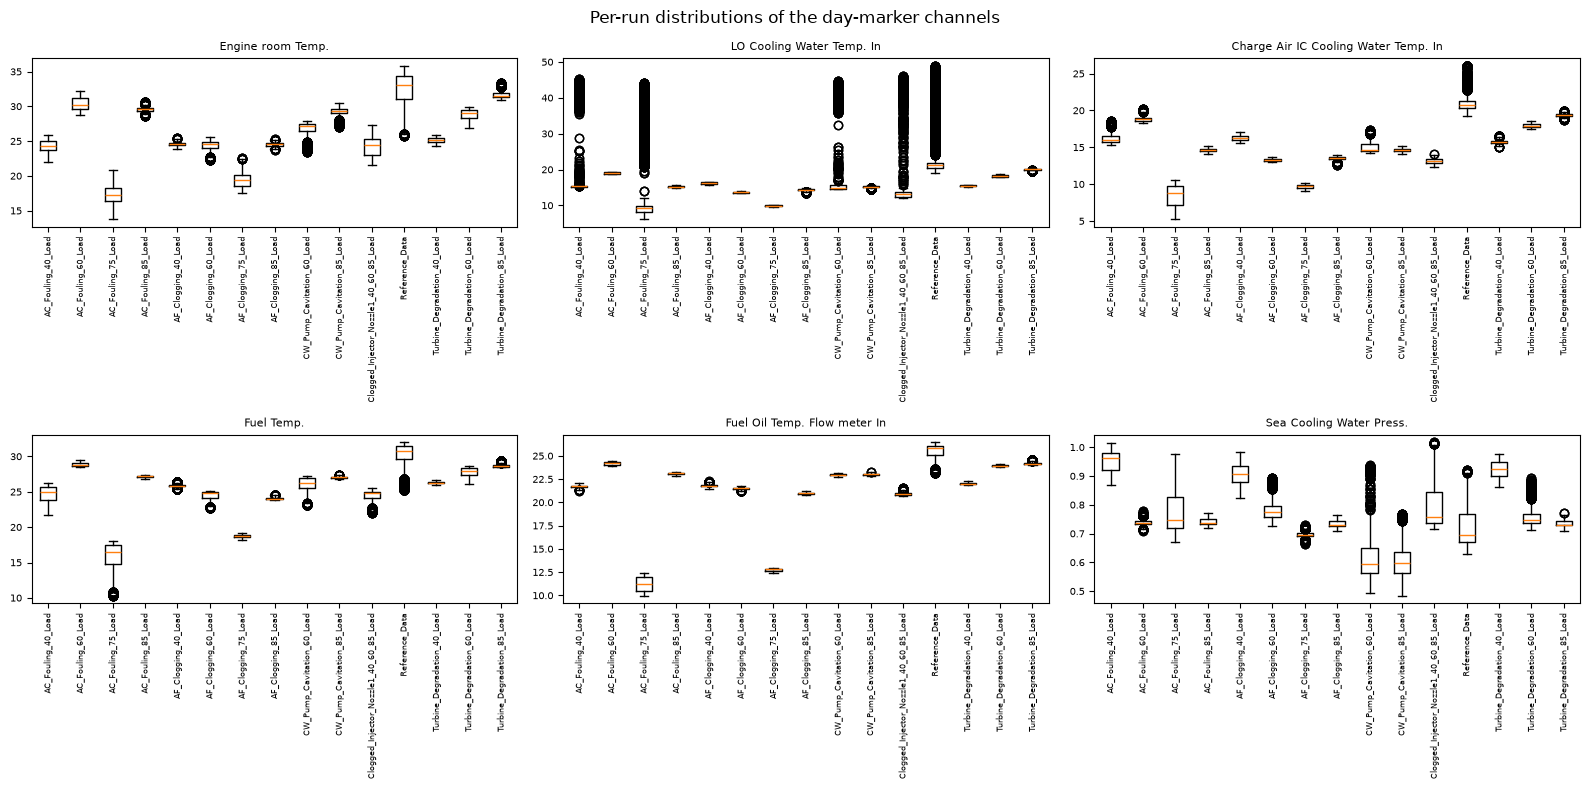

In [13]:
DAY_MARKER_CHANNELS = [
    "Engine room Temp.",
    "LO Cooling Water Temp. In",
    "Charge Air IC Cooling Water Temp. In",
    "Fuel Temp.",
    "Fuel Oil Temp. Flow meter In",
    "Sea Cooling Water Press.",
]
ALL_RUNS = sorted(full_table["run"].unique())

day_marker_rows = []
for channel in DAY_MARKER_CHANNELS:
    for run in ALL_RUNS:
        own = full_table.loc[full_table["run"] == run, channel].dropna()
        other = full_table.loc[full_table["run"] != run, channel].dropna()
        day_marker_rows.append(
            {
                "channel": channel,
                "run": run,
                "median": own.median(),
                "other_runs_median": other.median(),
                "z_vs_other_runs": (own.median() - other.median()) / other.std(),
            }
        )
day_markers = pd.DataFrame(day_marker_rows)
day_markers.to_csv(paths.RESULTS / "01_day_markers.csv", index=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, channel in zip(axes.flat, DAY_MARKER_CHANNELS, strict=True):
    by_run = [full_table.loc[full_table["run"] == run, channel].dropna() for run in ALL_RUNS]
    ax.boxplot(by_run, tick_labels=ALL_RUNS, vert=True)
    ax.set_title(channel, fontsize=8)
    ax.tick_params(axis="x", labelrotation=90, labelsize=6)
    ax.tick_params(axis="y", labelsize=7)
fig.suptitle("Per-run distributions of the day-marker channels")
fig.tight_layout()
fig.savefig(paths.FIGURES / "01_day_markers.png", dpi=150)
plt.show()

`day_markers` shows the injector run (`Clogged_Injector_Nozzle1_...`)
sitting close to the pack on every one of these channels
(|z| below 1 throughout) — it is not the test-day outlier the checklist
worried about. The real outliers are `Reference_Data`, warm on all five
temperature channels (z around 1.2 to 2.0), and the two 75%-load runs
(`AC_Fouling_75_Load`, `AF_Clogging_75_Load`), cold on the same five
(z from -1.7 to -4.0) — two different test days at the extremes of the
ambient range, unrelated to load or fault. `Sea Cooling Water Press.`
behaves differently: it clusters by load (the 40%-load runs read high,
CW's two runs read low) rather than by day, so it looks more like a
load-linked supply-pressure effect than a day marker.

**Day markers and what to do with them:** `Engine room Temp.`, `LO
Cooling Water Temp. In`, `Charge Air IC Cooling Water Temp. In`, `Fuel
Temp.` and `Fuel Oil Temp. Flow meter In` all move together with ambient
conditions on the day of the run, independent of fault or load — feature
engineering should residualise them against a same-run healthy baseline
(`eda.matched_healthy`) rather than use their raw levels, so a model does
not learn "which day" instead of "which fault". `Engine room Temp.` is
already excluded from model inputs by `keyframe.features.EXCLUDED_COLUMNS`;
the other four are not currently excluded and should be residualised, not
dropped, since their *shape* around switch-on can still carry fault
information (as it does for AF above). `Sea Cooling Water Press.` is not a
day marker on this evidence and can be kept as-is.

## Completing the checklist: the derived physics quantities

The Expected tables also name quantities that are not raw channels:
cooler effectiveness, the exhaust/Pmax/indicated-work spreads, cooling
water rise and the turbine temperature drop. `keyframe.eda` already has a
pure function for each; add them as columns and reuse `eda.fault_shift`
so they get the same standardised shift and std ratio as everything else.
`Loss in Charge Air IC` (Qrej_air), `Charge Air IC Cooling Water Temp. Out`
(T17), `Charge Air Press.` (Pturb), `Fuel Flow`, `Indicated Efficiency`
and `Effective Efficiency` are already raw channels.

In [14]:
full_table["Cooler Effectiveness"] = eda.cooler_effectiveness(full_table)
full_table["Exhaust Temp Spread"] = eda.exhaust_temp_spread(full_table)
full_table["Pmax Spread"] = eda.pmax_spread(full_table)
full_table["Indicated Work Spread"] = eda.indicated_work_spread(full_table)
full_table["Turbine Temp Drop"] = eda.turbine_temp_drop(full_table)
full_table["Cooling Water Rise"] = eda.cooling_water_rise(full_table)
full_table["Fuel Flow per kW"] = eda.fuel_flow_per_kw(full_table)

DERIVED_CHECKLIST_CHANNELS = [
    "Cooler Effectiveness",
    "Loss in Charge Air IC",
    "Charge Air IC Cooling Water Temp. Out",
    "Fuel Flow per kW",
    "Exhaust Temp Spread",
    "Pmax Spread",
    "Indicated Work Spread",
    "Indicated Efficiency",
    "Effective Efficiency",
    "Cooling Water Rise",
    "Turbine Temp Drop",
]

derived_shift_frames = []
for run in FAULT_RUNS:
    shift_table = eda.fault_shift(full_table, run, DERIVED_CHECKLIST_CHANNELS)
    shift_table.insert(0, "run", run)
    derived_shift_frames.append(shift_table)
derived_shifts = pd.concat(derived_shift_frames, ignore_index=True)
derived_shifts.to_csv(paths.RESULTS / "01_checklist_derived_shifts.csv", index=False)
derived_shifts

,run,channel,healthy_mean,healthy_std,faulty_mean,faulty_std,shift,std_ratio,last30_mean,last30_shift
0,AC_Fouling_40_Load,Cooler Effectiveness,0.486142,0.124046,0.294449,0.125096,-1.545336,1.008462,0.190583,-2.382655
1,AC_Fouling_40_Load,Loss in Charge Air IC,65.034634,16.621784,73.317814,10.687149,0.498333,0.642960,81.308665,0.979078
2,AC_Fouling_40_Load,Charge Air IC Cooling Water Temp. Out,33.805273,2.753507,36.710364,3.159261,1.055051,1.147359,39.852211,2.196086
3,AC_Fouling_40_Load,Fuel Flow per kW,0.261507,0.011291,0.261882,0.001978,0.033159,0.175170,0.262758,0.110732
4,AC_Fouling_40_Load,Exhaust Temp Spread,33.016123,2.721322,38.711945,2.197986,2.093035,0.807691,40.288876,2.672508
...,...,...,...,...,...,...,...,...,...,...
149,Turbine_Degradation_85_Load,Indicated Work Spread,4120.531717,3939.919751,2594.988637,1437.259364,-0.387202,0.364794,2713.581029,-0.357101
150,Turbine_Degradation_85_Load,Indicated Efficiency,36.551309,2.907595,35.982109,1.295262,-0.195763,0.445475,35.776819,-0.266368
151,Turbine_Degradation_85_Load,Effective Efficiency,32.773596,0.454540,32.461981,0.272480,-0.685560,0.599463,32.282315,-1.080830
152,Turbine_Degradation_85_Load,Cooling Water Rise,5.378276,22.607449,4.462160,13.623133,-0.040523,0.602595,4.743551,-0.028076


CW's checklist row also asks for the *rolling* std ratio of `Pl_water1`
(Fresh Cooling Water Press.) and `Qw_eng` (Engine Cooling water flow), not
the whole-window std ratio: `01_cavitation_rolling_std.png` already showed
whole-window std ratios below 1 even though the fault is a fluctuation
effect, because a single std over the last 30 minutes averages the jump
away. Rolling std (60 s window, same helper as the cavitation section)
measures the fluctuation directly instead.

In [15]:
cw_rolling_rows = []
for run in cw_runs:
    own = full_table[full_table["run"] == run].sort_values("t")
    faulty = own[own["label"] != "Normal"]
    healthy = eda.matched_healthy(full_table, run)
    t_max = faulty["t"].max()
    last30 = faulty[faulty["t"] >= t_max - 30 * 60]
    for label in ["Fresh Cooling Water Press.", "Engine Cooling water flow"]:
        healthy_roll = eda.rolling_std(healthy[label], healthy["t"], window_s=60)
        last30_roll = eda.rolling_std(last30[label], last30["t"], window_s=60)
        cw_rolling_rows.append(
            {
                "run": run,
                "channel": label,
                "healthy_rolling_std_mean": healthy_roll.mean(),
                "last30_rolling_std_mean": last30_roll.mean(),
                "last30_rolling_std_ratio": last30_roll.mean() / healthy_roll.mean(),
            }
        )
cw_rolling = pd.DataFrame(cw_rolling_rows)
cw_rolling

,run,channel,healthy_rolling_std_mean,last30_rolling_std_mean,last30_rolling_std_ratio
0,CW_Pump_Cavitation_60_Load,Fresh Cooling Water Press.,0.024488,0.026762,1.092861
1,CW_Pump_Cavitation_60_Load,Engine Cooling water flow,0.000422,0.000202,0.477856
2,CW_Pump_Cavitation_85_Load,Fresh Cooling Water Press.,0.022378,0.024510,1.095279
3,CW_Pump_Cavitation_85_Load,Engine Cooling water flow,0.000274,0.001267,4.625213
